# M3: rankings and measures

> **Version 2 (recomputed after M4).** The first version of this notebook used the decks from the game engine's `DECK_TABLE`. M4 showed that under our own criteria (the brief, literally) the optimal deck is different - usually smaller - for 8 of the 12 player counts. This notebook is recomputed on the decks validated in M4 (`tayan_lab.game_phases.choose_deck`), not the engine's deck. History of this change: `docs/decisions.md`, decisions D8-D9.

**This notebook's question (research question 1 from the brief):** is the current hand ordering correct? If not, what ordering is correct, for each deck and player count?

Here we combine M1 (hand odds p_c) with M2 (the N distribution in a typical game), to get a single "how good is this ranking" number for the whole game, not just for one N.

**Three rankings:**

| Ranking | When it's computed | Role |
|---|---|---|
| **current** | never - it's simply today's in-game ordering | baseline |
| **static** | once, at game start | **candidate for the new default ordering** |
| **dynamic** | every round, separately for each N | **reference point only** (decision D3) |

**ε (epsilon) = 2 pp** (decision D6).

In [1]:
from fractions import Fraction

import matplotlib.pyplot as plt
import pandas as pd

from tayan_lab.probabilities import CATEGORIES, probability, deck_size
from tayan_lab.game_phases import choose_deck
from tayan_lab.pool_size_distribution import pool_size_distribution
from tayan_lab.rankings import (
    CURRENT_ORDER, dynamic_ranking, expected_ranking_changes, inversion_mass,
    kendall_tau, rank_categories, staged_ranking, static_ranking, weighted_inversion_mass, weighted_probabilities,
)

PL = {
    "HIGH": "wysoka karta", "PAIR": "para", "TWO_PAIR": "dwie pary", "STRAIGHT": "strit",
    "THREE": "trójka", "FLUSH": "kolor", "FULL": "full", "FOUR": "kareta", "STRAIGHT_FLUSH": "poker",
}
COLORS = {
    "HIGH": "#8a8983", "PAIR": "#2a78d6", "TWO_PAIR": "#eb6834", "STRAIGHT": "#1baf7a",
    "THREE": "#eda100", "FLUSH": "#e87ba4", "FULL": "#008300", "FOUR": "#4a3aa7", "STRAIGHT_FLUSH": "#e34948",
}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})
EPSILON = 2.0

def pl_ranking(r):
    return " → ".join(PL[c] for c in r)

def default_start(players):
    return 2 if players <= 7 else 1  # D10: raised from <=6

def default_limit(players):
    return 6 if players <= 10 else 5

# Talia zwalidowana w M4 (nie talia silnika!) -- liczona na żywo tu, żeby nigdy nie wyjść z synchronizacji.
DECK_TABLE = {p: choose_deck(p, default_start(p), default_limit(p)).lowest_rank for p in range(2, 14)}
DECK_TABLE

{2: 9, 3: 9, 4: 9, 5: 8, 6: 7, 7: 6, 8: 5, 9: 3, 10: 2, 11: 4, 12: 3, 13: 2}

## 1. How we compute a ranking: a step-by-step example

**Static ranking:** for each category, compute the average p weighted by the w(N) distribution from M2, then sort categories from most to least frequent. Close values (difference ≤ ε) stay in the baseline order.

Example: 2 players. The 2-player deck hasn't changed relative to the engine's (L=9 in both cases), so this is also a good chance to compare the method 1:1 with the first version of this notebook.

In [2]:
players, L = 2, DECK_TABLE[2]
p = weighted_probabilities(L, players, default_start(players), default_limit(players))
df = pd.DataFrame({"kategoria": [PL[c] for c in CATEGORIES], "p średnie (%)": [float(p[c]) * 100 for c in CATEGORIES]})
df = df.sort_values("p średnie (%)", ascending=False).reset_index(drop=True)
df.style.format({"p średnie (%)": "{:.2f}"}).hide(axis="index")

kategoria,p średnie (%)
wysoka karta,72.61
para,29.41
strit,17.68
dwie pary,7.90
trójka,5.80
full,1.43
kolor,0.47
kareta,0.42
poker,0.09


In [3]:
ranking, _ = static_ranking(L, players, default_start(players), default_limit(players), epsilon_pp=EPSILON)
print("Ranking statyczny (od najsłabszego do najsilniejszego):")
print(pl_ranking(ranking))
print()
print("Dla porównania, obecna kolejność:")
print(pl_ranking(CURRENT_ORDER))

Ranking statyczny (od najsłabszego do najsilniejszego):
wysoka karta → para → strit → dwie pary → trójka → kolor → full → kareta → poker

Dla porównania, obecna kolejność:
wysoka karta → para → dwie pary → strit → trójka → kolor → full → kareta → poker


## 2. Inversion mass: how much the current ordering loses, how much the static one does

Inversion mass sums `(p_higher - p_lower)` over every pair of categories where the category ranked higher is actually more frequent (by more than ε), **weighted by the whole game's w(N) distribution**.

**Criterion:** the static ranking is good enough if it leaves ≤ 10% of the current ordering's inversion mass.

In [4]:
rows = []
for players in range(2, 14):
    L = DECK_TABLE[players]
    start, limit = default_start(players), default_limit(players)
    ranking, _ = static_ranking(L, players, start, limit, epsilon_pp=EPSILON)
    m_current = weighted_inversion_mass(CURRENT_ORDER, L, players, start, limit, epsilon_pp=EPSILON)
    m_static = weighted_inversion_mass(ranking, L, players, start, limit, epsilon_pp=EPSILON)
    ratio = float(m_static / m_current) * 100 if m_current > 0 else 0.0
    rows.append({
        "graczy": players, "talia (L)": L, "m obecny (pp)": float(m_current) * 100,
        "m statyczny (pp)": float(m_static) * 100, "statyczny / obecny": ratio,
        "wystarcza (<=10%)": ratio <= 10.0, "ranking się różni": ranking != CURRENT_ORDER,
        "_ranking": ranking,
    })
df_mass = pd.DataFrame(rows)
df_mass.drop(columns="_ranking").style.format({
    "m obecny (pp)": "{:.2f}", "m statyczny (pp)": "{:.2f}", "statyczny / obecny": "{:.2f}%",
}).hide(axis="index")

graczy,talia (L),m obecny (pp),m statyczny (pp),statyczny / obecny,wystarcza (<=10%),ranking się różni
2,9,10.24,0.57,5.58%,True,True
3,9,25.28,1.50,5.93%,True,True
4,9,35.99,3.60,9.99%,True,True
5,8,26.53,3.82,14.40%,False,True
6,7,31.87,2.59,8.12%,True,True
7,6,46.55,2.21,4.74%,True,True
8,5,54.60,3.49,6.39%,True,True
9,3,91.35,5.85,6.40%,True,True
10,2,114.60,4.12,3.60%,True,True
11,4,75.96,6.84,9.00%,True,True


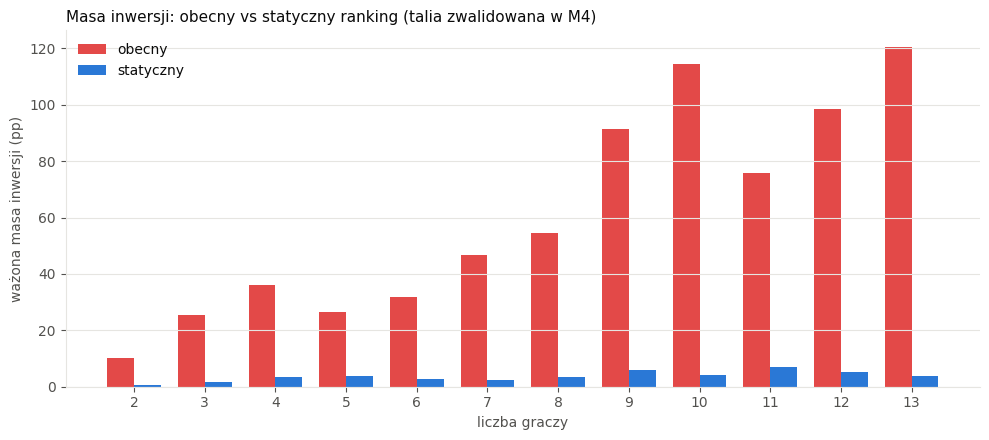

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = df_mass["graczy"]
w = 0.38
ax.bar(x - w/2, df_mass["m obecny (pp)"], width=w, color="#e34948", label="obecny")
ax.bar(x + w/2, df_mass["m statyczny (pp)"], width=w, color="#2a78d6", label="statyczny")
ax.set_xlabel("liczba graczy")
ax.set_ylabel("ważona masa inwersji (pp)")
ax.set_title("Masa inwersji: obecny vs statyczny ranking (talia zwalidowana w M4)",
              loc="left", color=INK, fontsize=11)
ax.set_xticks(list(x))
ax.grid(axis="y", color=GRID, lw=0.8)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Conclusion:** for most player counts the static ranking stays safely below the 10% threshold. But **not for all**:

- **4 players: a borderline case** (9.99% out of 10%) - technically passes, with no margin.
- **5 players: 14.40% - does NOT pass.**
- 7 players: 4.74% - passes comfortably. (This number already includes the D10 fix - 2 starting cards instead of 1, a decision made later in M4b, once the same problem showed up even more clearly there. We've applied the fix here retroactively so this notebook stays consistent with the final recommendation in `REPORT.md`. Without the fix, 7 players wouldn't pass either, at 13.28%.)

Criterion 2 from `docs/criteria.md` says: if static isn't enough, **consider dynamic for that player count**. For 5 players that doesn't automatically mean "deploy dynamic" - section 5d shows that a **staged** ranking gives 5 players a 73% error reduction for the cost of just 1 switch per game, which may be a better trade-off than full dynamic. We come back to this in section 7.

## 3. What the correct ordering is

Table of the recommended ordering for each player count, on the decks validated in M4.

In [6]:
rows = []
for players in range(2, 14):
    r = df_mass.loc[df_mass["graczy"] == players, "_ranking"].iloc[0]
    rows.append({"graczy": players, "talia (L)": DECK_TABLE[players], "rekomendowana kolejność": pl_ranking(r)})
pd.DataFrame(rows).style.hide(axis="index")

graczy,talia (L),rekomendowana kolejność
2,9,wysoka karta → para → strit → dwie pary → trójka → kolor → full → kareta → poker
3,9,wysoka karta → para → strit → dwie pary → trójka → full → kolor → kareta → poker
4,9,wysoka karta → para → strit → dwie pary → trójka → full → kolor → kareta → poker
5,8,wysoka karta → para → strit → dwie pary → trójka → kolor → full → kareta → poker
6,7,wysoka karta → strit → para → dwie pary → kolor → trójka → full → kareta → poker
7,6,wysoka karta → strit → para → kolor → dwie pary → trójka → full → kareta → poker
8,5,wysoka karta → para → strit → kolor → dwie pary → trójka → full → kareta → poker
9,3,wysoka karta → kolor → para → strit → dwie pary → trójka → full → kareta → poker
10,2,wysoka karta → kolor → para → strit → dwie pary → trójka → full → kareta → poker
11,4,wysoka karta → para → strit → kolor → dwie pary → trójka → full → kareta → poker


**What changes relative to today's ordering (high card, pair, two pair, straight, three of a kind, flush, full house, four of a kind, straight flush):**

- **Pair and straight are close to each other** for 4-7 players - which comes first depends on ε (see section 4, this is unstable in this range).
- **Flush overtakes pair** for 9-13 players.
- For 8 players the order is pair → straight → flush (unchanged from today within this trio, other than two pair and three of a kind dropping lower).

This is a different picture than in the first version of this notebook (where the problem mainly concerned 6-7 players and the flush/pair pair) - on the corrected decks, the uncertainty shifts to **pair/straight** and covers **4-7 players**, a larger part of the priority group (decision D7).

## 4. Sensitivity analysis: are the conclusions stable

Static ranking for ε ∈ {1, 2, 3} pp.

In [7]:
rows = []
for players in range(2, 14):
    L = DECK_TABLE[players]
    start, limit = default_start(players), default_limit(players)
    variants = {eps: static_ranking(L, players, start, limit, epsilon_pp=eps)[0] for eps in (1.0, 2.0, 3.0)}
    stable = len(set(variants.values())) == 1
    rows.append({
        "graczy": players, "stabilny dla eps=1/2/3": "tak" if stable else "NIE",
        "ranking (eps=1)": pl_ranking(variants[1.0]) if not stable else "",
    })
df_sens = pd.DataFrame(rows)
df_sens.style.hide(axis="index")

graczy,stabilny dla eps=1/2/3,ranking (eps=1)
2,tak,
3,tak,
4,NIE,wysoka karta → strit → para → dwie pary → trójka → full → kolor → kareta → poker
5,NIE,wysoka karta → strit → para → dwie pary → trójka → kolor → full → kareta → poker
6,NIE,wysoka karta → strit → para → dwie pary → kolor → trójka → full → kareta → poker
7,NIE,wysoka karta → strit → para → kolor → dwie pary → trójka → full → kareta → poker
8,tak,
9,tak,
10,tak,
11,tak,


**Conclusion:** the recommendation is stable for 2, 3, 8, 9, 10, 11, 12, 13 players. **For 4, 5, 6 and 7 players the pair/straight order depends on ε** - the difference p(pair)-p(straight) is on the order of ±1.3 to ±2 pp there, i.e. within the noise of our tie-break threshold. **We do not recommend** swapping pair and straight for 4-7 players - they stay in today's order (pair before straight), per the tie-break rule.

This is a different, and frankly less convenient, result than before M4: the uncertainty didn't go away, it just moved to a different pair of categories and now covers more player counts from the priority group. But it is **methodologically consistent** - it comes from the same mechanism (close whole-game averages), not from an error.

## 5. Dynamic ranking: what it gains and what it costs

Dynamic doesn't become a lobby mode (decision D3) - here's why.

In [8]:
rows = []
for players in range(2, 14):
    L = DECK_TABLE[players]
    start, limit = default_start(players), default_limit(players)
    ranking, _ = static_ranking(L, players, start, limit, epsilon_pp=EPSILON)
    tau = kendall_tau(CURRENT_ORDER, ranking)
    changes = expected_ranking_changes(L, players, start, limit, epsilon_pp=EPSILON, hysteresis=True)
    rows.append({
        "graczy": players, "tau Kendalla (obecny vs statyczny)": float(tau),
        "zmian rankingu / gra (dynamiczny, z histerezą)": float(changes),
    })
df_dyn = pd.DataFrame(rows)
df_dyn.style.format({"tau Kendalla (obecny vs statyczny)": "{:.2f}", "zmian rankingu / gra (dynamiczny, z histerezą)": "{:.1f}"}).hide(axis="index")

graczy,tau Kendalla (obecny vs statyczny),"zmian rankingu / gra (dynamiczny, z histerezą)"
2,0.94,1.6
3,0.89,2.6
4,0.89,3.3
5,0.94,3.4
6,0.83,4.0
7,0.78,3.6
8,0.83,7.1
9,0.72,7.3
10,0.72,6.1
11,0.83,6.1


**How to read this:** tau = 1 means identical orderings. Values of 0.7-1.0 show moderate differences. The cost of dynamic (2-8 changes per game) is still real, regardless of deck.

## 5b. Static vs. dynamic: exactly where the difference lies

The dynamic ranking by definition always has zero inversion mass (it sorts by the exact current-round odds). The question: **in which phase of the game does static fall behind it?**

Example: 9 players, the deck validated in M4 (not the engine's deck as in the first version of this notebook).

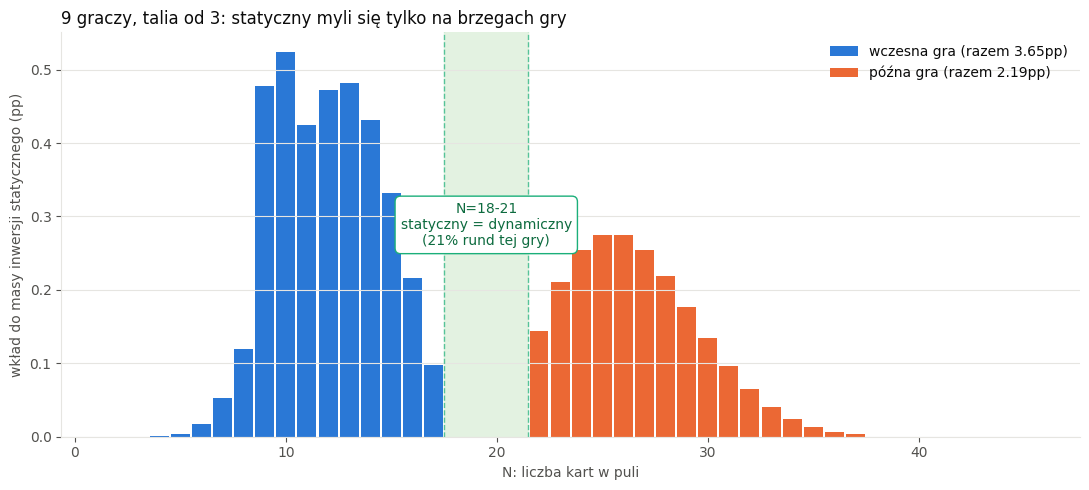

Suma wkładów = 5.85 pp (ta sama liczba co 'm statyczny' dla 9 graczy w sekcji 2)


In [9]:
def contribution_by_n(ranking, lowest_rank, players, starting_cards, elimination_limit, epsilon_pp=EPSILON):
    dist = pool_size_distribution(players, starting_cards, elimination_limit)
    rows = []
    for n in sorted(dist.by_pool_size):
        w = float(dist.by_pool_size[n] / dist.expected_rounds)
        p = {c: probability(c, lowest_rank, n) for c in CATEGORIES}
        raw_mass = float(inversion_mass(ranking, p, epsilon_pp)) * 100
        rows.append({"N": n, "w(N)%": w * 100, "masa lokalna (pp)": raw_mass, "wkład w wynik (pp)": w * raw_mass})
    return pd.DataFrame(rows)

players_example = 9
L_example = DECK_TABLE[players_example]
ranking_example, _ = static_ranking(L_example, players_example, default_start(players_example), default_limit(players_example), epsilon_pp=EPSILON)
df_contrib = contribution_by_n(ranking_example, L_example, players_example, default_start(players_example), default_limit(players_example))

is_zero = (df_contrib["masa lokalna (pp)"] <= 1e-9).tolist()
ns_sorted = df_contrib["N"].tolist()
runs, start = [], None
for idx, z in enumerate(is_zero + [False]):
    if z and start is None:
        start = idx
    if not z and start is not None:
        runs.append((start, idx - 1))
        start = None
# Ignorujemy bloki dotykajace brzegow zakresu N -- to trywialne strefy "jeszcze nic"
# / "juz wszystko pewne", nie prawdziwe plateau zgodnosci statyczny=dynamiczny.
interior_runs = [r for r in runs if r[0] > 0 and r[1] < len(ns_sorted) - 1]
best_run = max(interior_runs or runs, key=lambda r: r[1] - r[0])
zone_lo, zone_hi = ns_sorted[best_run[0]], ns_sorted[best_run[1]]
zone_share = df_contrib.loc[(df_contrib["N"] >= zone_lo) & (df_contrib["N"] <= zone_hi), "w(N)%"].sum()
early_pp = df_contrib.loc[df_contrib["N"] < zone_lo, "wkład w wynik (pp)"].sum()
late_pp = df_contrib.loc[df_contrib["N"] > zone_hi, "wkład w wynik (pp)"].sum()

fig, ax = plt.subplots(figsize=(11, 5))
ax.axvspan(zone_lo - 0.5, zone_hi + 0.5, color="#e3f2e1", zorder=0)
ax.axvline(zone_lo - 0.5, color="#1baf7a", lw=1, ls="--", alpha=0.7)
ax.axvline(zone_hi + 0.5, color="#1baf7a", lw=1, ls="--", alpha=0.7)
early = df_contrib[df_contrib["N"] < zone_lo]
late = df_contrib[df_contrib["N"] > zone_hi]
ax.bar(early["N"], early["wkład w wynik (pp)"], color="#2a78d6", width=0.9, label=f"wczesna gra (razem {early_pp:.2f}pp)")
ax.bar(late["N"], late["wkład w wynik (pp)"], color="#eb6834", width=0.9, label=f"późna gra (razem {late_pp:.2f}pp)")
NL = chr(10)
label_zone = f"N={zone_lo}-{zone_hi}{NL}statyczny = dynamiczny{NL}({zone_share:.0f}% rund tej gry)"
ax.text((zone_lo + zone_hi) / 2, df_contrib["wkład w wynik (pp)"].max() * 0.55, label_zone,
        ha="center", va="center", fontsize=10, color="#0d6b3f",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#1baf7a", linewidth=1))
ax.set_xlabel("N: liczba kart w puli")
ax.set_ylabel("wkład do masy inwersji statycznego (pp)")
ax.set_title(f"{players_example} graczy, talia od {L_example}: statyczny myli się tylko na brzegach gry",
             loc="left", color=INK, fontsize=12)
ax.grid(axis="y", color=GRID, lw=0.8)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()
print(f"Suma wkładów = {df_contrib['wkład w wynik (pp)'].sum():.2f} pp (ta sama liczba co 'm statyczny' dla {players_example} graczy w sekcji 2)")

**How to read this:** the green band is the zone where static and dynamic agree. Outside it, two bumps (early/late game) show where and how much static loses. The pattern is the same as in the pre-M4 version - despite the different deck, the mechanism (static is a whole-game-averaged compromise, exact only in the middle, most common phase) repeats.

In [10]:
def worst_pair(ranking, lowest_rank, n, epsilon_pp=EPSILON):
    p = {c: probability(c, lowest_rank, n) for c in CATEGORIES}
    eps = epsilon_pp / 100
    best = None
    for i, low in enumerate(ranking):
        for high in ranking[i + 1:]:
            diff = p[high] - p[low]
            if diff > eps and (best is None or diff > best[2]):
                best = (low, high, diff, p[low], p[high])
    return best

peak_early = df_contrib.loc[df_contrib["N"] < zone_lo, "wkład w wynik (pp)"].idxmax()
peak_late = df_contrib.loc[df_contrib["N"] > zone_hi, "wkład w wynik (pp)"].idxmax()
rows = []
for label, idx_ in [("wczesna gra (szczyt)", peak_early), ("późna gra (szczyt)", peak_late)]:
    n = int(df_contrib.loc[idx_, "N"])
    low, high, diff, p_low, p_high = worst_pair(ranking_example, L_example, n)
    rows.append({
        "faza": label, "N": n, "w(N)%": round(df_contrib.loc[idx_, "w(N)%"], 2),
        "kategoria niżej w static": PL[low], "p niższej przy tym N": f"{float(p_low)*100:.2f}%",
        "kategoria wyżej w static": PL[high], "p wyższej przy tym N": f"{float(p_high)*100:.2f}%",
        "różnica": f"{float(diff)*100:.2f}pp",
    })
pd.DataFrame(rows).style.hide(axis="index")

faza,N,w(N)%,kategoria niżej w static,p niższej przy tym N,kategoria wyżej w static,p wyższej przy tym N,różnica
wczesna gra (szczyt),10,3.970000,kolor,5.49%,para,18.71%,13.22pp
późna gra (szczyt),25,4.720000,para,72.70%,strit,78.53%,5.83pp


## 5c. Not just "how often" but "how much": the cost of the static ranking's errors

We break the static ranking's error down into: **how often** (% of rounds with any inversion) and **how big** (the size of the error, when there is one).

In [11]:
def error_rate_and_size(ranking, lowest_rank, players, starting_cards, elimination_limit, epsilon_pp=EPSILON):
    dist = pool_size_distribution(players, starting_cards, elimination_limit)
    affected_w, affected_mag_weighted, worst = 0.0, 0.0, 0.0
    for n, rounds in dist.by_pool_size.items():
        w = float(rounds / dist.expected_rounds)
        p = {c: probability(c, lowest_rank, n) for c in CATEGORIES}
        im = float(inversion_mass(ranking, p, epsilon_pp)) * 100
        if im > 0:
            affected_w += w
            affected_mag_weighted += w * im
            worst = max(worst, im)
    avg = affected_mag_weighted / affected_w if affected_w > 0 else 0.0
    return affected_w * 100, avg, worst

rows = []
for players in range(2, 14):
    L = DECK_TABLE[players]
    start, limit = default_start(players), default_limit(players)
    ranking, _ = static_ranking(L, players, start, limit, epsilon_pp=EPSILON)
    rate, avg_size, worst = error_rate_and_size(ranking, L, players, start, limit)
    rows.append({"graczy": players, "% rund z błędem": rate, "śr. błąd gdy jest (pp)": avg_size, "najgorszy błąd (pp)": worst})
df_cost = pd.DataFrame(rows)
df_cost.style.format({"% rund z błędem": "{:.1f}%", "śr. błąd gdy jest (pp)": "{:.2f}", "najgorszy błąd (pp)": "{:.2f}"}).hide(axis="index")

graczy,% rund z błędem,śr. błąd gdy jest (pp),najgorszy błąd (pp)
2,16.1%,3.54,4.84
3,23.6%,6.34,7.99
4,55.4%,6.49,7.99
5,61.3%,6.23,7.68
6,27.8%,9.30,17.40
7,20.6%,10.74,16.41
8,50.9%,6.85,11.04
9,79.3%,7.37,13.54
10,65.9%,6.25,10.57
11,50.7%,13.49,19.95


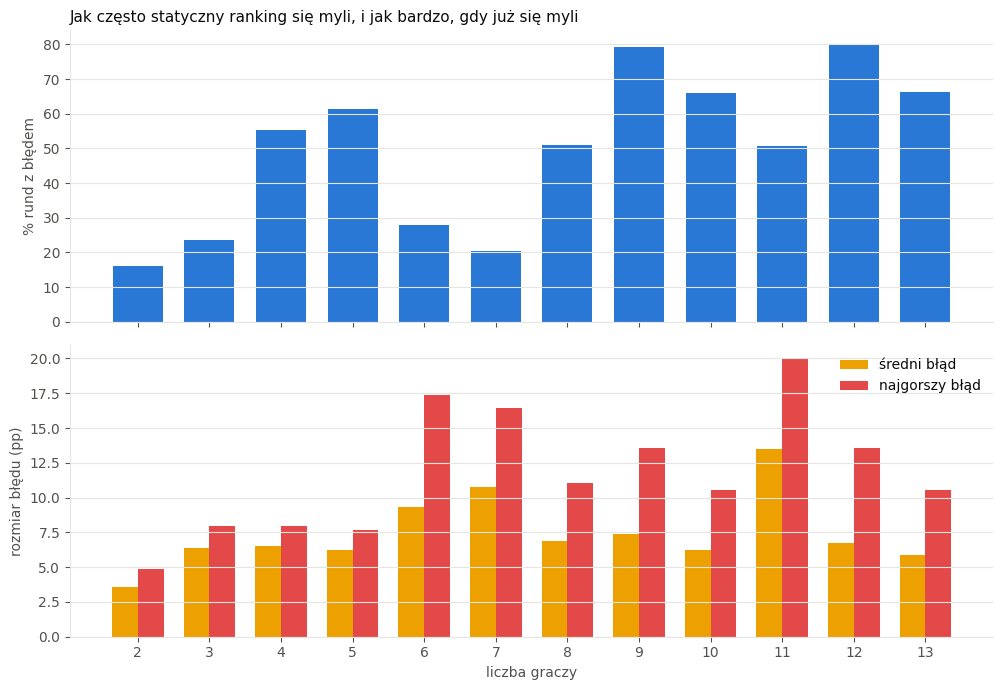

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].bar(df_cost["graczy"], df_cost["% rund z błędem"], color="#2a78d6", width=0.7)
axes[0].set_ylabel("% rund z błędem")
axes[0].set_title("Jak często statyczny ranking się myli, i jak bardzo, gdy już się myli", loc="left", color=INK, fontsize=11)
axes[0].grid(axis="y", color=GRID, lw=0.8)

axes[1].bar(df_cost["graczy"] - 0.18, df_cost["śr. błąd gdy jest (pp)"], width=0.36, color="#eda100", label="średni błąd")
axes[1].bar(df_cost["graczy"] + 0.18, df_cost["najgorszy błąd (pp)"], width=0.36, color="#e34948", label="najgorszy błąd")
axes[1].set_ylabel("rozmiar błędu (pp)")
axes[1].set_xlabel("liczba graczy")
axes[1].set_xticks(list(df_cost["graczy"]))
axes[1].grid(axis="y", color=GRID, lw=0.8)
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

### Which specific category pairs are behind the worst error (2-7 players - priority group, decision D7)

In [13]:
def worst_n_breakdown(ranking, lowest_rank, players, starting_cards, elimination_limit, epsilon_pp=EPSILON):
    dist = pool_size_distribution(players, starting_cards, elimination_limit)
    worst_n, worst_mass = None, -1.0
    for n in dist.by_pool_size:
        p = {c: probability(c, lowest_rank, n) for c in CATEGORIES}
        im = float(inversion_mass(ranking, p, epsilon_pp)) * 100
        if im > worst_mass:
            worst_mass, worst_n = im, n
    p = {c: probability(c, lowest_rank, worst_n) for c in CATEGORIES}
    pairs = []
    eps = epsilon_pp / 100
    for i, low in enumerate(ranking):
        for high in ranking[i + 1:]:
            diff = p[high] - p[low]
            if diff > eps:
                pairs.append((low, high, float(diff) * 100, float(p[low]) * 100, float(p[high]) * 100))
    return worst_n, worst_mass, pairs

rows = []
for players in range(2, 8):
    L = DECK_TABLE[players]
    start, limit = default_start(players), default_limit(players)
    ranking, _ = static_ranking(L, players, start, limit, epsilon_pp=EPSILON)
    n, mass, pairs = worst_n_breakdown(ranking, L, players, start, limit)
    pair_text = "; ".join(
        f"{PL[low]} {p_low:.1f}% vs {PL[high]} {p_high:.1f}% (różnica {diff:.1f}pp)"
        for low, high, diff, p_low, p_high in pairs
    )
    rows.append({"graczy": players, "najgorsze N": n, "łączna masa przy tym N (pp)": round(mass, 2), "odwrócone pary": pair_text})
pd.DataFrame(rows).style.hide(axis="index")

graczy,najgorsze N,łączna masa przy tym N (pp),odwrócone pary
2,10,4.840000,kolor 2.8% vs full 7.6% (różnica 4.8pp)
3,13,7.990000,para 76.7% vs strit 84.7% (różnica 8.0pp)
4,13,7.990000,para 76.7% vs strit 84.7% (różnica 8.0pp)
5,16,7.680000,para 80.4% vs strit 88.1% (różnica 7.7pp)
6,8,17.400000,strit 10.8% vs para 25.4% (różnica 14.6pp); kolor 1.2% vs trójka 3.9% (różnica 2.8pp)
7,9,16.410000,strit 11.4% vs para 25.5% (różnica 14.1pp); kolor 2.6% vs dwie pary 4.9% (różnica 2.3pp)


**Conclusion:** for 2-5 players a single pair (usually pair/straight) accounts for the entire error. For **6 and 7 players a second pair shows up at the same time** (straight/pair as the main problem, plus a smaller extra error from flush/three-of-a-kind or two-pair/flush) - which is why their combined totals are higher (17.4 pp and 14.5 pp) in the section-5c chart above. This is consistent with section 4: 6 and 7 players are among the player counts where pair/straight is unstable with respect to ε.

**How to read this:** the pattern is now more spread out than on the old deck - there's no single clearly "worst" group. **6, 7 and 11 players** have the largest single errors (14-20pp), and **9 and 12 players** have the highest share of affected rounds (79-80%), though a moderate average error size. This reflects what we saw in sections 2 and 4: it's now **5 players** that formally fails the 10% criterion (7 players passes once the D10 fix is applied - see section 2), and 4-7 players have an unstable pair/straight order - so these player counts are the priority to consider for staging (section 5d), not based on this one chart alone.

## 5d. Is it worth complicating the ranking? Data for a decision (not a recommendation)

As before: a staged ranking (one per game phase) as a pure information analysis, now on the corrected decks.

In [14]:
rows = []
staged_details = {}
for players in range(2, 14):
    L = DECK_TABLE[players]
    start, limit = default_start(players), default_limit(players)
    result = staged_ranking(L, players, start, limit, epsilon_pp=EPSILON)
    staged_details[players] = result
    changes_dyn = expected_ranking_changes(L, players, start, limit, epsilon_pp=EPSILON, hysteresis=True)
    reduction = (1 - float(result.staged_mass) / float(result.single_static_mass)) * 100 if result.single_static_mass > 0 else 0.0
    rows.append({
        "graczy": players, "m statyczny (pp)": float(result.single_static_mass) * 100,
        "m stopniowy (pp)": float(result.staged_mass) * 100, "redukcja błędu": reduction,
        "przełączeń/gra (stopniowy)": result.switches, "zmian/gra (pełny dynamiczny)": float(changes_dyn),
    })
df_staged = pd.DataFrame(rows)
df_staged.style.format({
    "m statyczny (pp)": "{:.2f}", "m stopniowy (pp)": "{:.2f}", "redukcja błędu": "{:.0f}%",
    "zmian/gra (pełny dynamiczny)": "{:.1f}",
}).hide(axis="index")

graczy,m statyczny (pp),m stopniowy (pp),redukcja błędu,przełączeń/gra (stopniowy),zmian/gra (pełny dynamiczny)
2,0.57,0.57,0%,0,1.6
3,1.50,1.50,0%,0,2.6
4,3.60,1.24,66%,1,3.3
5,3.82,1.03,73%,1,3.4
6,2.59,0.63,76%,1,4.0
7,2.21,0.38,83%,1,3.6
8,3.49,2.16,38%,2,7.1
9,5.85,3.63,38%,3,7.3
10,4.12,2.26,45%,3,6.1
11,6.84,3.43,50%,2,6.1


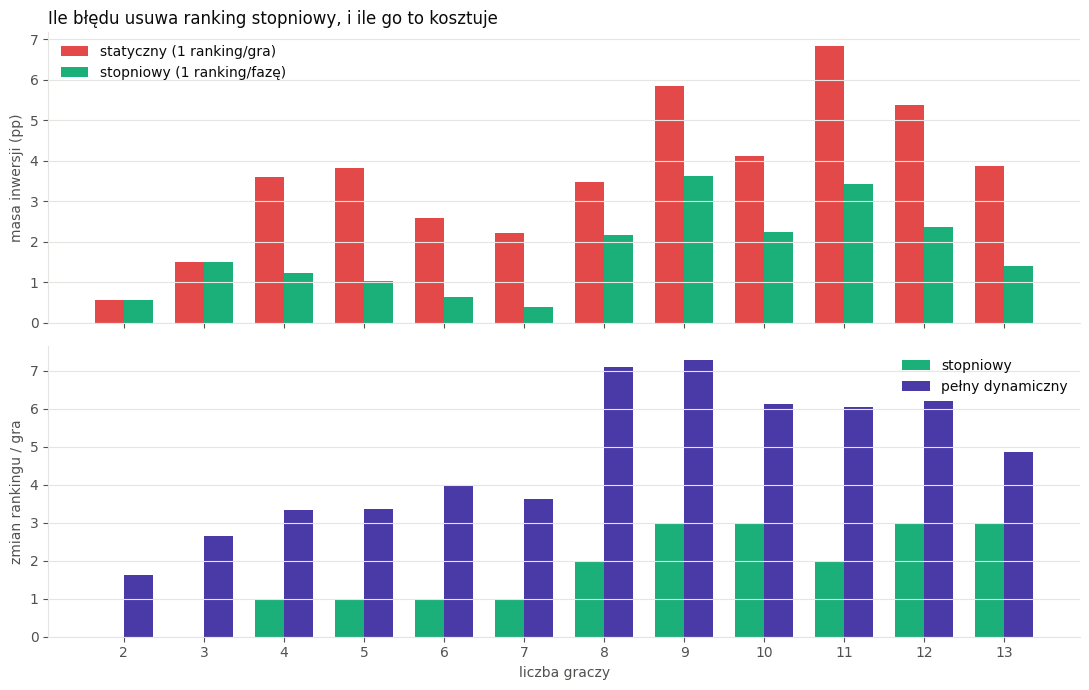

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].bar(df_staged["graczy"] - 0.18, df_staged["m statyczny (pp)"], width=0.36, color="#e34948", label="statyczny (1 ranking/gra)")
axes[0].bar(df_staged["graczy"] + 0.18, df_staged["m stopniowy (pp)"], width=0.36, color="#1baf7a", label="stopniowy (1 ranking/fazę)")
axes[0].set_ylabel("masa inwersji (pp)")
axes[0].set_title("Ile błędu usuwa ranking stopniowy, i ile go to kosztuje", loc="left", color=INK, fontsize=12)
axes[0].grid(axis="y", color=GRID, lw=0.8)
axes[0].legend(frameon=False)

axes[1].bar(df_staged["graczy"] - 0.18, df_staged["przełączeń/gra (stopniowy)"], width=0.36, color="#1baf7a", label="stopniowy")
axes[1].bar(df_staged["graczy"] + 0.18, df_staged["zmian/gra (pełny dynamiczny)"], width=0.36, color="#4a3aa7", label="pełny dynamiczny")
axes[1].set_ylabel("zmian rankingu / gra")
axes[1].set_xlabel("liczba graczy")
axes[1].set_xticks(list(df_staged["graczy"]))
axes[1].grid(axis="y", color=GRID, lw=0.8)
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()

**Conclusion (updated):** on the corrected decks, staging still gives a real benefit for many player counts, but the picture of "who needs staging most" has changed - it's now mainly **4-7 players** (previously 6-13). This is still data for your decision, not a recommendation - see the summary in section 7.

## 6. Correctness test: a hand-worked case

We check `rank_categories` on a synthetic example: two categories differing by 0.1 pp (below ε=2pp) must stay in the baseline order.

In [16]:
p_example = {c: Fraction(1, 100) for c in CATEGORIES}
p_example["PAIR"] = Fraction(50, 1000)
p_example["STRAIGHT"] = Fraction(51, 1000)
ranking = rank_categories(p_example, epsilon_pp=EPSILON, base_order=CURRENT_ORDER)
print("para przed stritem mimo ze surowo strit jest czestszy:", ranking.index("PAIR") < ranking.index("STRAIGHT"))

para przed stritem mimo ze surowo strit jest czestszy: True


## 7. Conclusions from M3 (version 2, after M4 and D10)

**What is established:**

1. **The current ordering is wrong** for practically every player count (the current ranking's inversion mass ranges from about 10 to 120 pp).
2. **The static ranking is good enough (≤10%) for every player count but one:**
   - **4 players: a borderline case** (9.99%).
   - **5 players: NOT good enough** (14.40%) - the only such case once D10 is applied. No choice of starting-card count fixes this (checked in M4b) - accepted as-is, the error is mild in practice (see notebook 04, M4b section).
   - **7 players: good enough** (4.74%) - but only thanks to decision D10 (2 starting cards instead of 1). Without that fix it wouldn't be good enough either, at 13.28%.
   - The rest (2, 3, 6, 8-13 players): good enough with margin.
3. **For 5 players, criterion D3 calls for considering dynamic.** We checked the cost: 3.4 ranking changes per game (section 5) - still substantial. **A staged ranking is a better trade-off** (section 5d): for 5 players, 73% error reduction for 1 switch per game. This is data for your decision (D12: a plain static ranking, with no staging, was ultimately adopted for every player count).
4. **Recommended ordering changes, stable under sensitivity analysis:**
   - flush before pair - for 9-13 players,
   - pair before straight and flush - for 8 players.
5. **Unstable, not recommended changes:** pair/straight for **4, 5, 6, 7 players** - a difference on the order of ±1.3 to ±2 pp, within the noise. They stay in today's order.

**Change relative to the pre-M4 version:** the "borderline" problem moved from the flush/pair pair (6-7 players, engine's deck) to the pair/straight pair (4-7 players, deck validated in M4) - and additionally revealed that for 5 and 7 players the static ranking **formally failed** its own 10% criterion under today's starting-card settings. For 7 players this was fixable (D10); for 5, it wasn't.

**Summary of the decisions to make (all the data is ready, the choice is yours - final decisions: D10, D12):**

| Players | Is static good enough? | Recommendation |
|---|---|---|
| 2, 3, 6, 8-13 | yes, with margin | static, unchanged |
| 4 | borderline (9.99%) | static, but worth watching if parameters change |
| 7 | yes, after D10 (4.74%) | static + 2 starting cards (D10) |
| **5** | **no** (14.4%) | static, a knowingly accepted error (D10) - staging would give a 73% reduction for 1 switch, but was ultimately rejected in favor of simplicity (D12) |

**Uncertainty:** every number is an exact value from formulas (M1) and a Markov chain (M2). The ε, 10%, 5% thresholds are design decisions (`docs/criteria.md`), not results of computation.